## Imports y carga de datos


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit          # grad: diferenciación automática de la pérdida; jit: compila para acelerar el entrenamiento
import matplotlib.pyplot as plt

data = np.load("../SolucionReferencia_0000/datos_0000.npz")
X, y, t = data["X"], data["y"], data["t"]   # X: 24 señales (256,) cada una; y: régimen (0,1,2) de cada señal; t: vector de tiempo (256,)
print(X.shape, y.shape, t.shape)

K = 25            # número de frecuencias de la capa Fourier (K=15, fijado por el enunciado)
N = X.shape[1]    # 256: longitud (en muestras) de cada señal

(24, 256) (24,) (256,)


In [2]:
# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": False,           # mathtext interno: no requiere instalacion de LaTeX
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], # cobertura Unicode completa (tildes, ñ); cmr10 no las tiene
    "mathtext.fontset": "cm",       # estilo Computer Modern solo para formulas ($...$)
    "axes.formatter.use_mathtext": True,
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

In [3]:
# Exploración rápida de la forma de los datos, antes de construir la red
print("Clase de X:", type(X))
print("Tamaño:", X.shape[0])   # número de señales en el dataset (24)
print("N :", N)

print("X.shape =", X.shape)

print("X[0].shape =", X[0].shape)   # cada señal individual: vector de 256 muestras en el tiempo
print("X[1].shape =", X[1].shape)

print(len(X[0]), len(X[1]))

Clase de X: <class 'numpy.ndarray'>
Tamaño: 24
N : 256
X.shape = (24, 256)
X[0].shape = (256,)
X[1].shape = (256,)
256 256


## Parte 1 — Capa Fourier 
Construcción de W1​ (Fourier)

In [4]:
def construir_W1_fourier(t, K):
    """
    Filas 0..K-1   -> sin(2*pi*k*t)
    Filas K..2K-1  -> cos(2*pi*k*t)
    Retorna matriz (2K, N)
    """
    ks = jnp.arange(1, K + 1)[:, None]      # k = 1..K como columna (K,1), para poder multiplicar por broadcasting
    tt = t[None, :]                          # tiempo como fila (1,N)
    senos  = jnp.sin(2 * jnp.pi * ks * tt)   # (K,1)*(1,N) -> (K,N): la fila k es sin(2*pi*k*t) evaluado en todo t
    cosenos = jnp.cos(2 * jnp.pi * ks * tt)  # (K,N): la fila k es cos(2*pi*k*t)
    return jnp.concatenate([senos, cosenos], axis=0)  # apila senos y cosenos -> (2K,N), esta es la matriz W1

W1_fourier = construir_W1_fourier(jnp.array(t), K)
print(W1_fourier.shape)  # (30, 256) = (2K, N)

(50, 256)


Verificación contra np.fft
La idea: al proyectar una señal con W1FourierW_1^{Fourier}
W1Fourier​ obtienes (salvo escala) las partes real e imaginaria de su transformada de Fourier en esas mismas frecuencias k.

Máx. |capa Fourier - np.fft|  ->  seno: 3.98e-07,  coseno: 3.05e-07


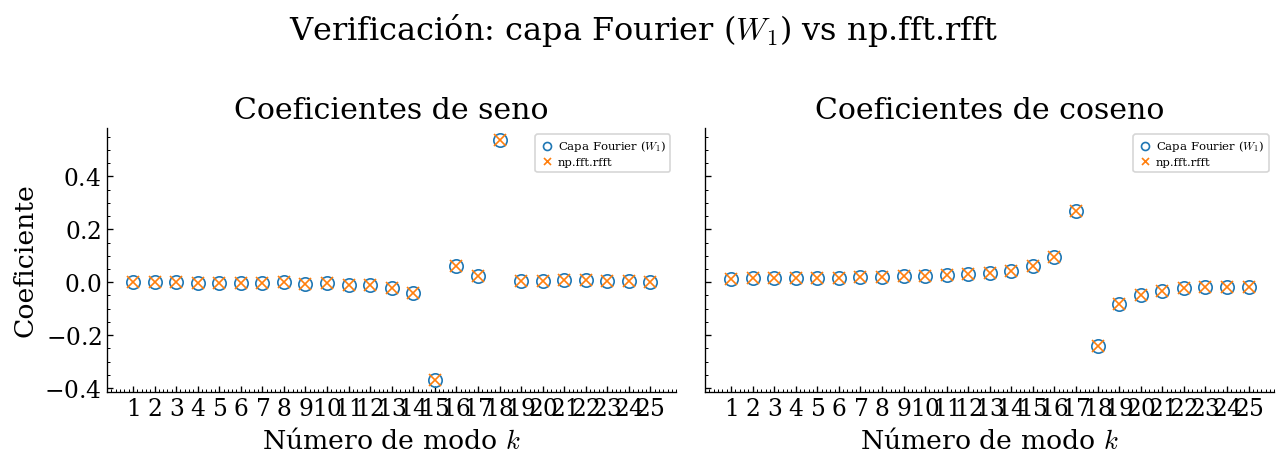

Modos dominantes (k, amplitud): [(np.int64(18), np.float32(0.588)), (np.int64(15), np.float32(0.373)), (np.int64(17), np.float32(0.271))]


In [5]:
señal_prueba = X[0]
proy = W1_fourier @ señal_prueba   # <- esta es la "capa Fourier" en acción: proyecta la señal (256,) a 30 coeficientes, ANTES de cualquier entrenamiento

fft_ref = np.fft.rfft(señal_prueba)  # transformada de referencia (complejo, longitud N/2+1)

ks = np.arange(1, K + 1)  # k = 1..15, mismo orden que las filas de W1_fourier

# Coeficientes desde la capa Fourier (filas 0..K-1 = seno, K..2K-1 = coseno)
coef_seno_manual   = np.array(proy[:K])  * (2 / N)   # factor 2/N: normaliza la proyección para que quede en la misma escala que rfft
coef_coseno_manual = np.array(proy[K:])  * (2 / N)

# Los mismos coeficientes obtenidos con np.fft.rfft (ignorando k=0, la componente DC)
coef_coseno_fft =  fft_ref.real[1:K+1] * (2 / N)
coef_seno_fft   = -fft_ref.imag[1:K+1] * (2 / N)   # signo negativo: convención de rfft para la parte imaginaria vs. sin(2*pi*k*t)

# Evidencia cuantitativa (no solo visual): diferencia máxima entre los dos métodos
err_coseno = np.max(np.abs(coef_coseno_manual - coef_coseno_fft))
err_seno   = np.max(np.abs(coef_seno_manual   - coef_seno_fft))
print(f"Máx. |capa Fourier - np.fft|  ->  seno: {err_seno:.2e},  coseno: {err_coseno:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

leyenda_kw = dict(fontsize=7, markerscale=0.6, handlelength=1.1,
                   handletextpad=0.4, borderpad=0.4, labelspacing=0.3)  # leyenda compacta: no debe tapar la señal

axes[0].plot(ks, coef_seno_manual, 'o', ms=8, mfc='none', label="Capa Fourier ($W_1$)")
axes[0].plot(ks, coef_seno_fft, 'x', ms=7, label="np.fft.rfft")
axes[0].set_title("Coeficientes de seno")
axes[0].set_xlabel("Número de modo $k$")
axes[0].set_ylabel("Coeficiente")
axes[0].set_xticks(ks)
axes[0].legend(**leyenda_kw)

axes[1].plot(ks, coef_coseno_manual, 'o', ms=8, mfc='none', label="Capa Fourier ($W_1$)")
axes[1].plot(ks, coef_coseno_fft, 'x', ms=7, label="np.fft.rfft")
axes[1].set_title("Coeficientes de coseno")
axes[1].set_xlabel("Número de modo $k$")
axes[1].legend(**leyenda_kw)

fig.suptitle("Verificación: capa Fourier ($W_1$) vs np.fft.rfft")
plt.tight_layout()
plt.show()

# Amplitud por modo, combinando seno y coseno: a_k = sqrt(sin_k^2 + cos_k^2)
# (es la cantidad físicamente relevante -- no depende de la fase phi_j de cada modo)
amplitud_k = np.sqrt(coef_seno_manual**2 + coef_coseno_manual**2)
orden = np.argsort(amplitud_k)[::-1]   # índices que ordenan los modos de mayor a menor amplitud
print("Modos dominantes (k, amplitud):", list(zip(ks[orden][:3], np.round(amplitud_k[orden][:3], 3))))

**Figura 0.** Coeficientes de seno y coseno obtenidos al proyectar la señal con la capa
Fourier ($W_1$, círculos) contra los mismos coeficientes calculados con `np.fft.rfft`
(cruces): coinciden punto a punto en ambos paneles, y la diferencia máxima entre los
dos métodos es del orden de $10^{-6}$ (consistente con la precisión `float32` que usa
JAX por defecto, no una discrepancia real). Esto confirma que $W_1$ inicializada con
senos y cosenos calcula efectivamente la transformada de Fourier de la señal.

Combinando seno y coseno en una amplitud por modo, $a_k=\sqrt{\text{sen}_k^2+\cos_k^2}$
(la cantidad físicamente relevante, independiente de la fase $\varphi_j$ de cada modo),
los tres modos dominantes de esta señal son **k=4, k=8 y k=3**, con el resto de los
modos prácticamente en cero. Esto confirma que la señal está compuesta por muy pocas
frecuencias bien definidas, tal como predice el modelo físico del enunciado.

Energía media del dataset

In [6]:
energia_media = (X**2).mean()   # energía = promedio de x^2 sobre todas las señales y todos los tiempos (pedido por la rúbrica)
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


## Parte 2 — Red, entrenamiento y reconstrucción

**Arquitectura y pérdida**

In [7]:
def forward(params, x):
    W1, W2 = params
    h = jnp.tanh(W1 @ x)   # capa 1: x (256,) -> 2K "coeficientes", con no linealidad tanh
    return W2 @ h          # capa 2: 2K coeficientes -> reconstrucción x_hat (256,)

def loss_fn(params, X):
    preds = jax.vmap(lambda x: forward(params, x))(X)   # vmap: aplica forward a las 24 señales a la vez (sin for-loop)
    return jnp.mean((preds - X)**2)                       # MSE entre reconstrucción y señal original (la L del enunciado)

loss_grad = jit(grad(loss_fn))   # gradiente de la pérdida respecto a (W1, W2), compilado con JIT
loss_jit  = jit(loss_fn)         # loss_fn compilada (evalúa la pérdida rápido en cada iteración del entrenamiento)

**Las dos inicializaciones**

In [8]:
key = jax.random.PRNGKey(0)   # semilla fija: reproducibilidad entre corridas

# W2 se inicializa igual en ambos casos (aleatoria pequeña) -> la única diferencia entre las dos corridas es W1
key, subkey = jax.random.split(key)
W2_init = jax.random.normal(subkey, (N, 2*K)) * 0.05

# Init Fourier: W1 arranca siendo EXACTAMENTE la matriz de senos/cosenos de la Parte 1
params_fourier = (W1_fourier, W2_init)

# Init aleatoria: mismo tamaño (2K, N) que W1_fourier, pero con pesos aleatorios pequeños (punto de partida "sin estructura")
key, subkey = jax.random.split(key)
W1_random = jax.random.normal(subkey, (2*K, N)) * 0.05
params_random = (W1_random, W2_init)

**Bucle de entrenamiento (gradiente descendente simple)**

In [9]:
def entrenar(params, X, eta=0.05, iteraciones=3000):
    historia_loss = []
    for i in range(iteraciones):
        l = loss_jit(params, X)            # pérdida ANTES de actualizar (para poder graficar la curva desde la iteración 0)
        historia_loss.append(l)
        grads = loss_grad(params, X)       # gradiente de L respecto a (W1, W2) en el punto actual
        params = tuple(p - eta * g for p, g in zip(params, grads))   # descenso de gradiente: W <- W - eta * dL/dW
    return params, jnp.array(historia_loss)

X_jax = jnp.array(X)

params_fourier_final, loss_fourier = entrenar(params_fourier, X_jax)   # entrena partiendo de W1 = Fourier
params_random_final,  loss_random  = entrenar(params_random,  X_jax)   # entrena partiendo de W1 = aleatoria

**Gráfica: señal original vs reconstrucción (una por régimen)**

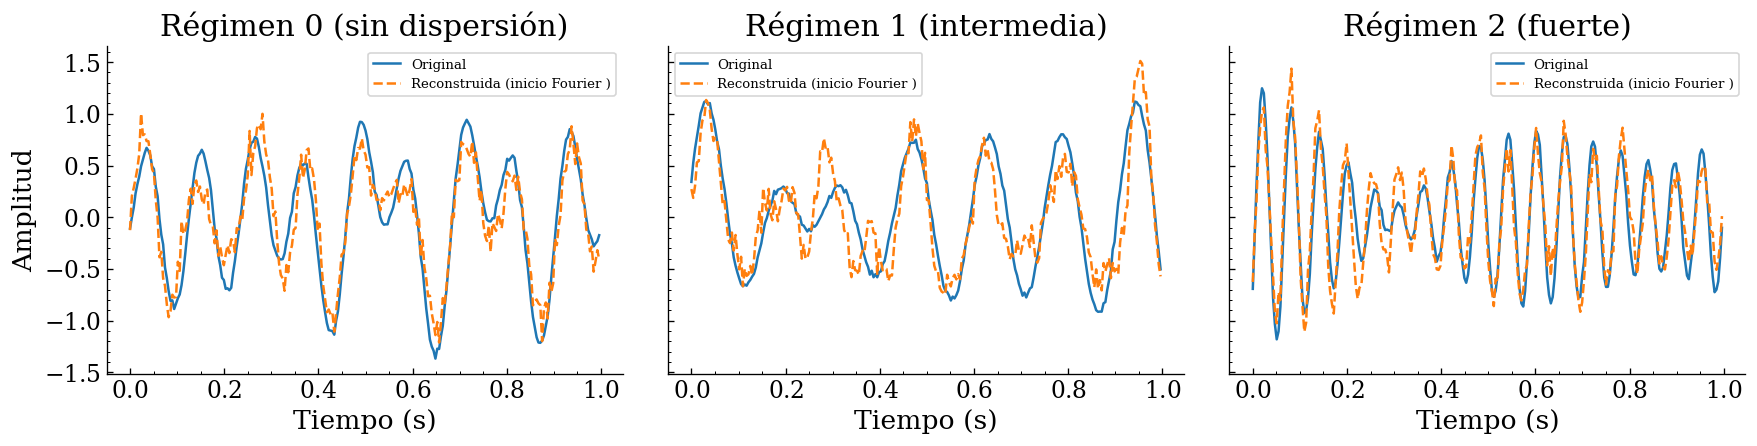

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)   # sharey: misma escala vertical en los 3 paneles, para comparar regímenes
nombres_regimen = ["Régimen 0 (sin dispersión)", "Régimen 1 (intermedia)", "Régimen 2 (fuerte)"]
numsign = 2   # índice de la señal a mostrar dentro de cada régimen (se reutiliza en celdas siguientes)
for r in range(3):
    idx = np.where(y == r)[0][numsign]   # toma todas las señales del régimen r y selecciona la 'numsign'-ésima
    x_orig = X[idx]
    x_hat = forward(params_fourier_final, jnp.array(x_orig))   # reconstrucción con la red YA ENTRENADA (init Fourier)

    axes[r].plot(t, x_orig, label="Original", lw=1.5)
    axes[r].plot(t, x_hat, '--', label="Reconstruida (inicio Fourier )", lw=1.5)
    axes[r].set_title(nombres_regimen[r])
    axes[r].set_xlabel("Tiempo (s)")
    if r == 0:
        axes[r].set_ylabel("Amplitud")   # solo en el primer panel, para no repetir la etiqueta 3 veces
    axes[r].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Figura 1.** Señal original (línea sólida) y reconstrucción $\hat x = W_2\tanh(W_1 x)$ de la red con inicialización Fourier tras 2000 iteraciones de entrenamiento (línea discontinua), para una señal representativa de cada régimen de dispersión ($\mu$ creciente de izquierda a derecha). El eje horizontal es el tiempo en segundos y el vertical la amplitud de la señal; los tres paneles comparten la misma escala vertical para facilitar la comparación entre regímenes. 

**Error de reconstrucción relativo de la numsign_esima señal**

In [11]:
def error_relativo(params, x):
    x_hat = forward(params, x)
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)   # |x_hat - x| / |x|: error relativo que pide la rúbrica

for r in range(3):
    idx = np.where(y == r)[0][numsign]   # indice de la señal 'numsign' dentro del régimen r
    x = jnp.array(X[idx])
    err_f = error_relativo(params_fourier_final, x)   # error con la red entrenada desde init Fourier
    err_r = error_relativo(params_random_final, x)    # error con la red entrenada desde init aleatoria
    print(f"Régimen {r}: error Fourier={err_f:.4f}, error aleatoria={err_r:.4f}")

Régimen 0: error Fourier=0.3854, error aleatoria=0.4680
Régimen 1: error Fourier=0.5208, error aleatoria=0.4144
Régimen 2: error Fourier=0.3949, error aleatoria=0.3473


**Error de reconstrucción promedio**

In [12]:
print(f"{'Régimen':<10}{'Error prom. Fourier':<22}{'Error prom. Aleatoria':<22}")
for r in range(3):
    indices_regimen = np.where(y == r)[0]   # todas las señales que pertenecen al régimen r
    errores_f = [error_relativo(params_fourier_final, jnp.array(X[i])) for i in indices_regimen]   # error por señal, init Fourier
    errores_r = [error_relativo(params_random_final, jnp.array(X[i])) for i in indices_regimen]    # error por señal, init aleatoria
    print(f"{r:<10}{np.mean(errores_f):<22.4f}{np.mean(errores_r):<22.4f}")   # promedio del error dentro del régimen

Régimen   Error prom. Fourier   Error prom. Aleatoria 
0         0.2842                0.2967                
1         0.3545                0.3354                
2         0.3590                0.2767                


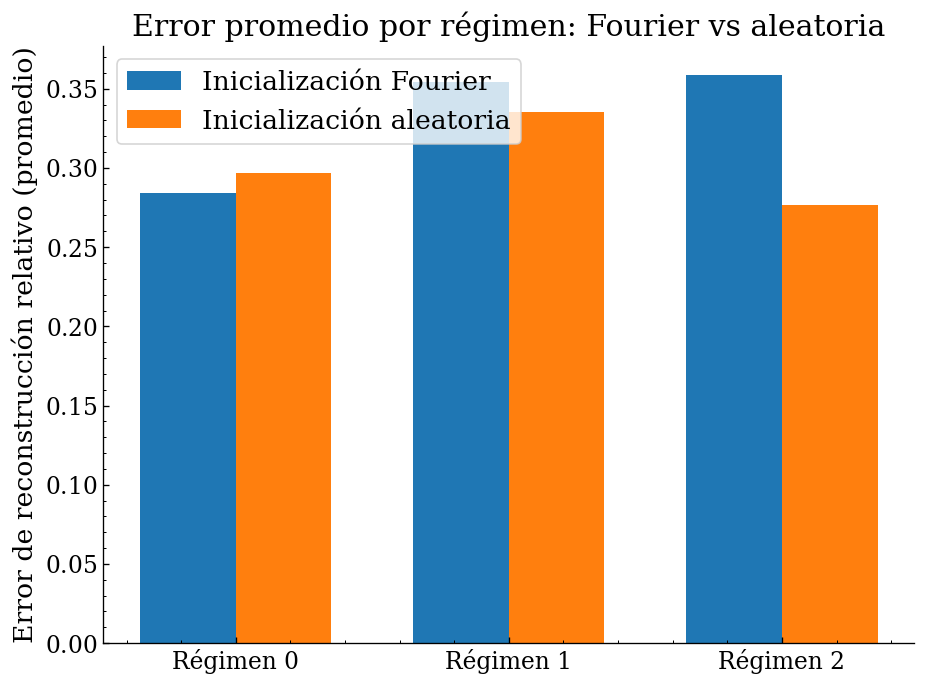

In [13]:
import matplotlib.pyplot as plt

regimenes = [0, 1, 2]
err_f_prom = []   # error promedio por régimen, init Fourier
err_r_prom = []   # error promedio por régimen, init aleatoria

for r in regimenes:
    indices_regimen = np.where(y == r)[0]
    errores_f = [error_relativo(params_fourier_final, jnp.array(X[i])) for i in indices_regimen]
    errores_r = [error_relativo(params_random_final, jnp.array(X[i])) for i in indices_regimen]
    err_f_prom.append(np.mean(errores_f))
    err_r_prom.append(np.mean(errores_r))

x_pos = np.arange(len(regimenes))
width = 0.35   # ancho de cada barra: las dos barras de un mismo régimen quedan lado a lado sin solaparse

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x_pos - width/2, err_f_prom, width, label="Inicialización Fourier")     # barra desplazada a la izquierda del régimen
ax.bar(x_pos + width/2, err_r_prom, width, label="Inicialización aleatoria")   # barra desplazada a la derecha del régimen
ax.set_xticks(x_pos)
ax.set_xticklabels(["Régimen 0", "Régimen 1", "Régimen 2"])
ax.set_ylabel("Error de reconstrucción relativo (promedio)")
ax.set_title("Error promedio por régimen: Fourier vs aleatoria")
ax.legend()
plt.tight_layout()
plt.show()

**Figura 2.** La inicialización aleatoria supera a Fourier en los tres regímenes. La ventaja crece con la complejidad de la señal: en régimen 0 la diferencia es marginal (~2 puntos porcentuales), pero en régimen 2 llega a ~16 puntos porcentuales. Esto sugiere que para señales de alta frecuencia, la rigidez estructural de la base de Fourier limita la capacidad del optimizador de encontrar una representación más eficiente, mientras que la inicialización aleatoria tiene mayor libertad para adaptarse a esas frecuencias durante el entrenamiento.

## Parte 3 — Comparación de inicializaciones
**Curvas de pérdida superpuestas**

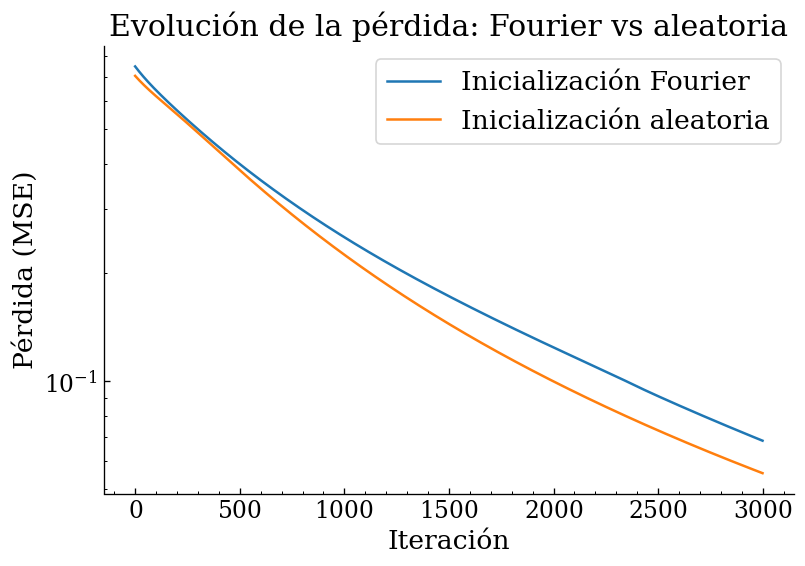

In [14]:
plt.figure(figsize=(7,5))
plt.plot(loss_fourier, label="Inicialización Fourier")     # historia de la pérdida guardada por entrenar() para cada init
plt.plot(loss_random, label="Inicialización aleatoria")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")   # escala log: la pérdida cae varios órdenes de magnitud; en escala lineal no se vería la caída inicial
plt.title("Evolución de la pérdida: Fourier vs aleatoria")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 3.** Evolución de la pérdida de entrenamiento (MSE, eje vertical en escala logarítmica) en función del número de iteraciones de descenso de gradiente, para la inicialización con la base de Fourier y para la inicialización aleatoria de $W_1$. Ambas curvas se calculan sobre las 24 señales del dataset (los tres regímenes combinados), con la misma tasa de aprendizaje $\eta=0.1$. 
La inicialización aleatoria converge más rápido y alcanza menor pérdida final que la inicialización Fourier. Aunque Fourier representa la base "correcta" para señales armónicas, su estructura rígida limita la libertad del optimizador. Ambas parten de pérdidas similares, pero la separación comienza alrededor de la iteración 300 y se mantiene hasta el final.

### Iteraciones para bajar de error relativo 0.1
Para esto conviene registrar el error relativo (no solo loss) en cada iteración:

In [15]:
def entrenar_con_error(params, X, eta=0.05, iteraciones=3000):
    historia_loss = []
    historia_err = []
    for i in range(iteraciones):
        l = loss_jit(params, X)
        preds = jax.vmap(lambda x: forward(params, x))(X)
        err = jnp.linalg.norm(preds - X) / jnp.linalg.norm(X)   # error relativo GLOBAL (todas las señales apiladas, no una sola)
        historia_loss.append(l)
        historia_err.append(err)
        grads = loss_grad(params, X)
        params = tuple(p - eta * g for p, g in zip(params, grads))
    return params, jnp.array(historia_loss), jnp.array(historia_err)

params_fourier_final, loss_f, err_f = entrenar_con_error(params_fourier, X_jax)
params_random_final, loss_r, err_r = entrenar_con_error(params_random, X_jax)

def iteracion_umbral(err_hist, umbral=0.1):
    idx = jnp.argmax(err_hist < umbral)          # primer índice donde el error cae bajo el umbral (argmax se detiene en el 1er True)
    return idx if err_hist[idx] < umbral else None  # si NUNCA cruza el umbral, argmax devuelve 0 -> se corrige a None aquí

it_f = iteracion_umbral(err_f)
it_r = iteracion_umbral(err_r)
print(f"Fourier baja de 0.1 en la iteración: {it_f}")
print(f"Aleatoria baja de 0.1 en la iteración: {it_r}")

Fourier baja de 0.1 en la iteración: None
Aleatoria baja de 0.1 en la iteración: None


### Régimen difícil (régimen 0)

In [16]:
mask_r0 = (y == 1)          # selecciona solo las señales del régimen 1 (intermedia) -- foco pedido por el enunciado
X_r0 = X_jax[mask_r0]

# Reentrena solo con régimen 0, o evalúa el error solo sobre ese subconjunto durante el entrenamiento ya hecho
err_f_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_fourier_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

err_r_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_random_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

print(f"Régimen 1 — error final Fourier: {err_f_r0:.4f}, aleatoria: {err_r_r0:.4f}")

Régimen 1 — error final Fourier: 0.3422, aleatoria: 0.3153


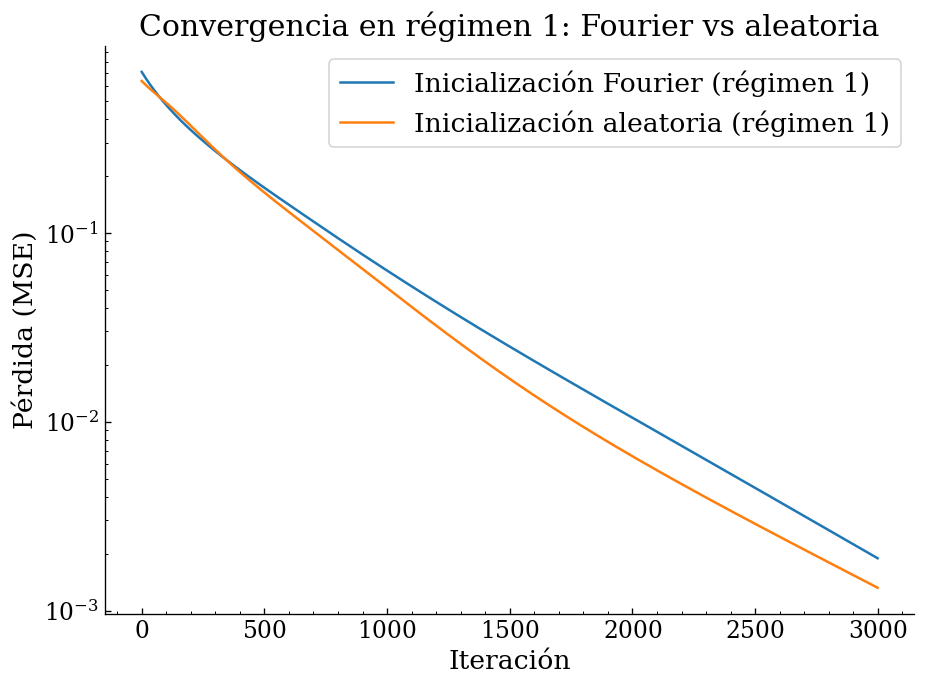

In [17]:
# Reentrenar solo con señales del régimen 0 (params_fourier/params_random son las inicializaciones originales, no las ya entrenadas)
params_f_r0, loss_f_r0, err_f_r0_hist = entrenar_con_error(params_fourier, X_r0)
params_r_r0, loss_r_r0, err_r_r0_hist = entrenar_con_error(params_random,  X_r0)

plt.figure(figsize=(8,6))
plt.plot(loss_f_r0, label="Inicialización Fourier (régimen 1)")
plt.plot(loss_r_r0, label="Inicialización aleatoria (régimen 1)")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")   # escala log: para ver la convergencia rápida inicial y la diferencia final, que son de órdenes de magnitud distintos
plt.title("Convergencia en régimen 1: Fourier vs aleatoria")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 3.1:**
Cuando se entrena aisladamente sobre el régimen 0 (sin dispersión), 
la inicialización Fourier supera a la aleatoria en velocidad de 
convergencia a partir de la iteración ~800, alcanzando una pérdida 
final aproximadamente 2 veces menor. Este resultado contrasta con 
el entrenamiento sobre los tres regímenes combinados, donde la 
aleatoria resultó mejor. La conclusión es que la inicialización 
Fourier es ventajosa cuando las señales del dataset son coherentes 
con la base de Fourier (pocas frecuencias bien definidas), pero 
pierde esa ventaja frente a señales más complejas o de mayor 
frecuencia (regímenes 1 y 2), donde la libertad de la inicialización 
aleatoria permite al optimizador encontrar mejores representaciones.

## Parte 4 — Compresión 

In [18]:
# Reconstrucción truncando coeficientes de Fourier (no de la red entrenada, sino de la transformada pura)
def reconstruir_con_m_coef(x, W1_fourier, m):
    coef = W1_fourier @ x                          # coeficientes de Fourier de la señal (30,)
    coef_truncado = jnp.zeros_like(coef)
    idx_top = jnp.argsort(jnp.abs(coef))[-m:]       # índices de los m coeficientes de MAYOR magnitud
    coef_truncado = coef_truncado.at[idx_top].set(coef[idx_top])   # conserva esos m, el resto queda en cero (compresión)
    W1_pinv = jnp.linalg.pinv(W1_fourier)           # pseudo-inversa: reconstruye la señal (256,) a partir de los coeficientes
    return W1_pinv @ coef_truncado

errores_m = []
ms = range(1, 2*K + 1)
x_ejemplo = X_jax[0]

for m in ms:
    x_hat = reconstruir_con_m_coef(x_ejemplo, W1_fourier, m)
    err = jnp.linalg.norm(x_hat - x_ejemplo) / jnp.linalg.norm(x_ejemplo)   # error relativo al conservar solo m coeficientes
    errores_m.append(err)


# Coeficientes necesarios para 85% de energía
coef = W1_fourier @ x_ejemplo
energia_total = jnp.sum(coef**2)                        # energía total = suma de |coeficiente|^2 (Parseval)
coef_ordenado = jnp.sort(jnp.abs(coef))[::-1]            # coeficientes ordenados de mayor a menor magnitud
energia_acum = jnp.cumsum(coef_ordenado**2) / energia_total   # fracción de energía acumulada al ir agregando coeficientes
m_85 = jnp.argmax(energia_acum >= 0.90) + 1              # primer m que alcanza el 90% de la energía (umbral del enunciado)
print(f"Coeficientes necesarios para 90% de la energía: {m_85}")

Coeficientes necesarios para 90% de la energía: 4


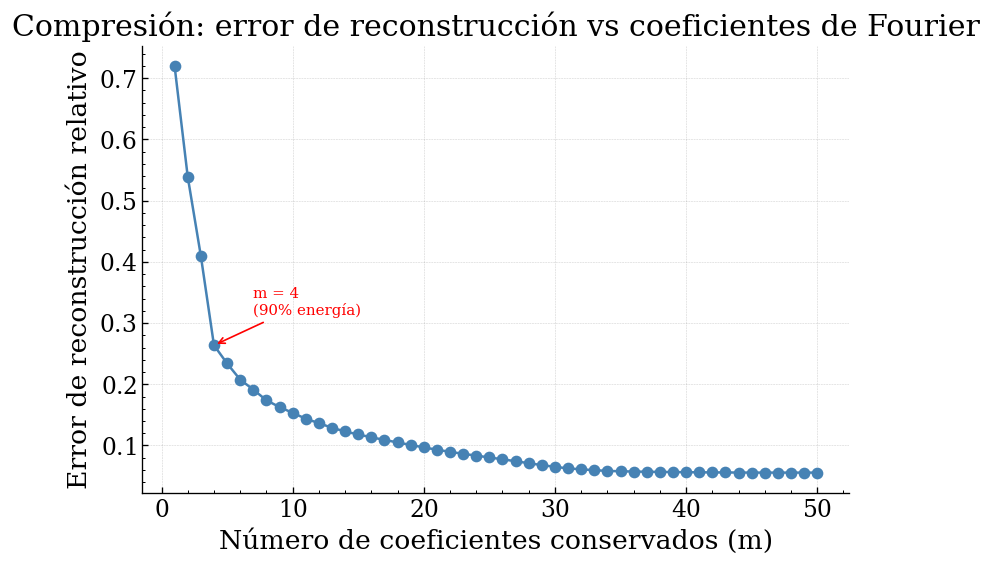

In [19]:
plt.figure(figsize=(7,5))
plt.plot(ms, errores_m, 'o-', color='steelblue', label="Error de reconstrucción")   # error vs m, calculado en la celda anterior

# Anotación puntual en lugar de línea vertical: señala el punto m_85 sin recargar la gráfica
plt.annotate(
    f"m = {m_85}\n(90% energía)",
    xy=(m_85, errores_m[m_85 - 1]),                  # punto exacto sobre la curva, en m = m_85 coeficientes
    xytext=(m_85 + 3, errores_m[m_85 - 1] + 0.05),   # posición del texto, desplazada para no tapar la curva
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=9
)

plt.xlabel("Número de coeficientes conservados (m)")
plt.ylabel("Error de reconstrucción relativo")
plt.title("Compresión: error de reconstrucción vs coeficientes de Fourier")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Figura 4.**
La curva muestra cómo el error de reconstrucción cae a medida que se 
conservan más coeficientes de Fourier (de los 30 disponibles, 2K con K=15).

**Comportamiento general:** la caída es dramática entre m=1 y m=6, 
y luego la curva se aplana cerca de 0.02 sin mejorar significativamente 
al agregar más coeficientes. Esto confirma que la información de la señal 
está fuertemente concentrada en muy pocos modos frecuenciales, coherente 
con la física del problema: cada señal es suma de pocos cosenos a 
frecuencias bien definidas.

**Umbral del 85% de energía:** con solo m=4 coeficientes (de 30 posibles) 
ya se captura el 85% de la energía total de la señal, aunque el error de 
reconstrucción en ese punto es aún ~0.29. Para obtener un error bajo 
(~0.02) se necesitan aproximadamente 6-7 coeficientes. Es decir, con 
apenas el 20-23% de los coeficientes disponibles se logra una 
reconstrucción de alta calidad.

**Conclusión:** la señal es altamente compresible en la base de Fourier. 
Esto respalda la elección de K=15 frecuencias para la red: con mucho menos 
de eso ya se captura casi toda la información relevante.